✅ Dataset Loaded Successfully
Total Students: 1000
   gender    Group    Parent Education         lunch  Test Prep  math score  \
0  female  group B   bachelor's degree      standard       none          72   
1  female  group C        some college      standard  completed          69   
2  female  group B     master's degree      standard       none          90   
3    male  group A  associate's degree  free/reduced       none          47   
4    male  group C        some college      standard       none          76   

   reading score  writing score  Total    Average Grade  
0             72             74    218  72.666667     B  
1             90             88    247  82.333333     A  
2             95             93    278  92.666667    A+  
3             57             44    148  49.333333     F  
4             78             75    229  76.333333     B  

===== MAIN MENU =====
1. Show Dashboard
2. Run ML Models
3. Predict Score
4. Clustering
0. Exit
👉 Enter your choice: 3

🔮 Pre

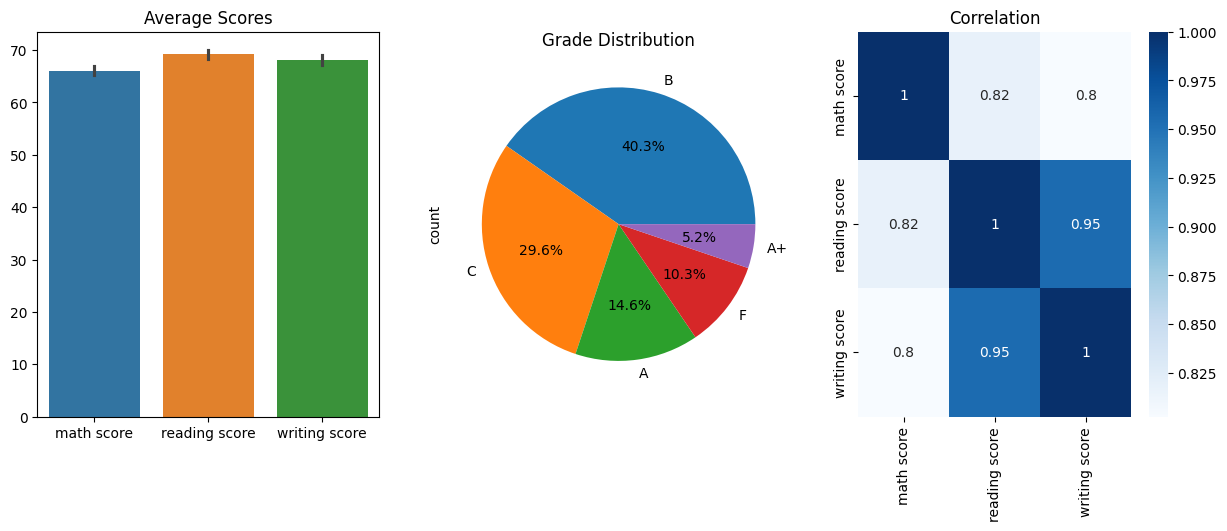


✅ Task Completed! Choose next option...

===== MAIN MENU =====
1. Show Dashboard
2. Run ML Models
3. Predict Score
4. Clustering
0. Exit
❌ Please enter a number!

===== MAIN MENU =====
1. Show Dashboard
2. Run ML Models
3. Predict Score
4. Clustering
0. Exit
👉 Enter your choice: 2

📊 MODEL PERFORMANCE:
Logistic       : 0.74
Decision Tree  : 0.92
Random Forest  : 0.95
KNN            : 0.96
SVM            : 0.96
Naive Bayes    : 0.95

✅ Task Completed! Choose next option...

===== MAIN MENU =====
1. Show Dashboard
2. Run ML Models
3. Predict Score
4. Clustering
0. Exit
👉 Enter your choice: 4


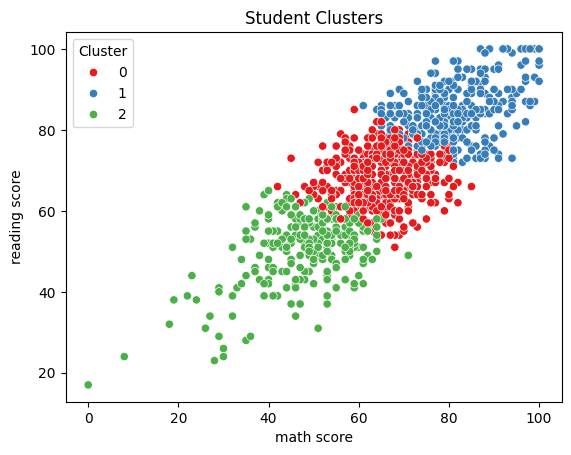


✅ Task Completed! Choose next option...

===== MAIN MENU =====
1. Show Dashboard
2. Run ML Models
3. Predict Score
4. Clustering
0. Exit
👉 Enter your choice: 0
👋 Exiting program...


In [5]:
# ============================================================
# 🎓 FINAL STUDENT PERFORMANCE ANALYSIS SYSTEM (CSV VERSION)
# ============================================================

# INSTALL (only first time)
!pip install pandas matplotlib seaborn scikit-learn -q

# IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings("ignore")

# ============================================================
# 📂 LOAD DATA (FROM COLAB / DRIVE)
# ============================================================

# 👉 Change path if needed. For example, if your file is in Google Drive, you might use '/content/drive/MyDrive/Studentsperformance.csv'
# Remember to mount Google Drive if your file is there (e.g., from google.colab import drive; drive.mount('/content/drive'))
FILE_PATH = "/content/drive/MyDrive/Studentsperformance.csv"

df = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/students.xlsx")

# ============================================================
# 🧹 DATA PROCESSING
# ============================================================

df.rename(columns={
    "race/ethnicity":"Group",
    "parental level of education":"Parent Education",
    "test preparation course":"Test Prep"
}, inplace=True)

# FEATURE ENGINEERING
df["Total"] = df[["math score","reading score","writing score"]].sum(axis=1)
df["Average"] = df[["math score","reading score","writing score"]].mean(axis=1)

# GRADE SYSTEM
def grade(avg):
    if avg>=90: return "A+"
    elif avg>=80: return "A"
    elif avg>=65: return "B"
    elif avg>=50: return "C"
    else: return "F"

df["Grade"] = df["Average"].apply(grade)

print("✅ Dataset Loaded Successfully")
print("Total Students:", len(df))
print(df.head())

# ============================================================
# 📊 VISUALIZATION
# ============================================================

def show_dashboard():
    plt.figure(figsize=(15,5))

    # BAR CHART
    plt.subplot(1,3,1)
    sns.barplot(data=df[["math score","reading score","writing score"]])
    plt.title("Average Scores")

    # PIE CHART
    plt.subplot(1,3,2)
    df["Grade"].value_counts().plot.pie(autopct='%1.1f%%')
    plt.title("Grade Distribution")

    # HEATMAP
    plt.subplot(1,3,3)
    sns.heatmap(df[["math score","reading score","writing score"]].corr(),
                annot=True, cmap="Blues")
    plt.title("Correlation")

    plt.show()

# ============================================================
# 🤖 MACHINE LEARNING PREPROCESSING
# ============================================================

df_ml = df.copy()

le = LabelEncoder()
for col in ["gender","Group","Parent Education","lunch","Test Prep","Grade"]:
    df_ml[col] = le.fit_transform(df_ml[col])

X = df_ml[["math score","reading score","writing score"]]
y = df_ml["Grade"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# ============================================================
# 🔥 MODELS
# ============================================================

def run_models():
    results = {}

    # Logistic Regression
    model = LogisticRegression(max_iter=200)
    model.fit(X_train,y_train)
    results["Logistic"] = accuracy_score(y_test,model.predict(X_test))

    # Decision Tree
    model = DecisionTreeClassifier()
    model.fit(X_train,y_train)
    results["Decision Tree"] = accuracy_score(y_test,model.predict(X_test))

    # Random Forest
    model = RandomForestClassifier()
    model.fit(X_train,y_train)
    results["Random Forest"] = accuracy_score(y_test,model.predict(X_test))

    # KNN
    model = KNeighborsClassifier()
    model.fit(X_train,y_train)
    results["KNN"] = accuracy_score(y_test,model.predict(X_test))

    # SVM
    model = SVC()
    model.fit(X_train,y_train)
    results["SVM"] = accuracy_score(y_test,model.predict(X_test))

    # Naive Bayes
    model = GaussianNB()
    model.fit(X_train,y_train)
    results["Naive Bayes"] = accuracy_score(y_test,model.predict(X_test))

    print("\n📊 MODEL PERFORMANCE:")
    for k,v in results.items():
        print(f"{k:15}: {v:.2f}")

# ============================================================
# 📈 LINEAR REGRESSION (PREDICTION)
# ============================================================

def linear_prediction():
    X_lr = df[["math score","reading score"]]
    y_lr = df["Average"]

    model = LinearRegression()
    model.fit(X_lr,y_lr)

    print("\n🔮 Predict Student Average Score")
    m = int(input("Enter Math Score: "))
    r = int(input("Enter Reading Score: "))

    pred = model.predict([[m,r]])
    print("Predicted Average Score:", round(pred[0],2))

# ============================================================
# 🔍 CLUSTERING (UNSUPERVISED)
# ============================================================

def clustering():
    kmeans = KMeans(n_clusters=3, random_state=42)
    df["Cluster"] = kmeans.fit_predict(X)

    sns.scatterplot(x=df["math score"], y=df["reading score"],
                    hue=df["Cluster"], palette="Set1")
    plt.title("Student Clusters")
    plt.show()

# ============================================================
# 🎯 MENU SYSTEM
# ============================================================

while True:
    print("\n===== MAIN MENU =====")
    print("1. Show Dashboard")
    print("2. Run ML Models")
    print("3. Predict Score")
    print("4. Clustering")
    print("0. Exit")

    try:
        ch = int(input("👉 Enter your choice: "))
    except:
        print("❌ Please enter a number!")
        continue

    if ch == 1:
        show_dashboard()

    elif ch == 2:
        run_models()

    elif ch == 3:
        linear_prediction()

    elif ch == 4:
        clustering()

    elif ch == 0:
        print("👋 Exiting program...")
        break

    else:
        print("❌ Invalid choice")

    print("\n✅ Task Completed! Choose next option...")